  This notebook computes all derived features for the injury prediction model and validates the results.   
                                                                                                           
  Features computed:                                                                                       
  - Workload Score
  - PER Change
  - Injury Flag
  - Age Risk Factor
  - Games Missed Last Season

In [2]:
import sys
import os
sys.path.insert(0,os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_features

In [3]:
df = build_features()
print(f'Totals rows: {len(df)}')
df.head()

Done. 11665 rows written to player_season_features.
Totals rows: 11665


,player_id,season,workload_score,per_change,injury_flag,age,age_risk_factor,games_missed_last_season
0,1,2022-23,0.732604,0.032773,1,38.0,34+,20
1,2,2022-23,0.538240,-0.133333,0,31.0,30-33,0
2,1,2021-22,0.685962,0.031729,1,37.0,34+,0
3,2,2021-22,0.509988,0.029630,0,30.0,30-33,0
4,1,2020-21,0.589306,NaN,0,36.0,34+,0


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
player_id                       0
season                          0
workload_score                  0
per_change                   2379
injury_flag                     0
age                         11659
age_risk_factor             11659
games_missed_last_season        0
dtype: int64


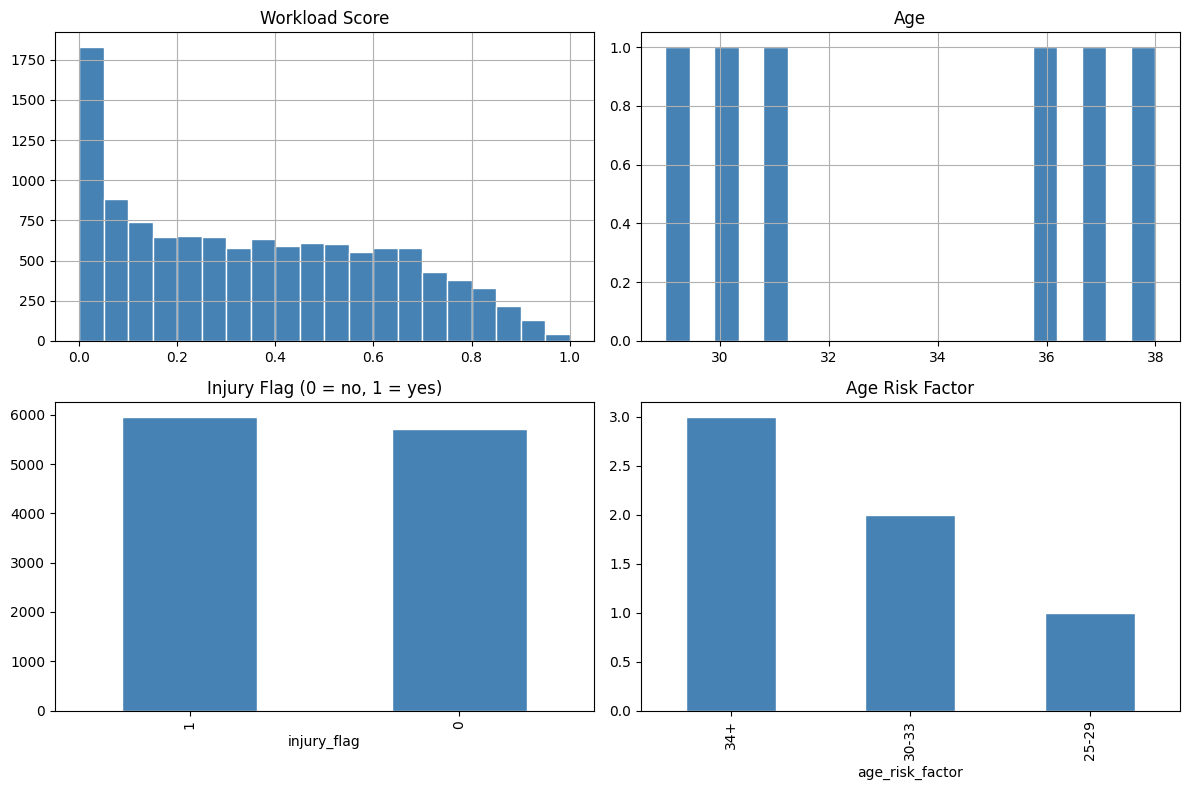

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['workload_score'].hist(bins=20, ax=axes[0,0], color='steelblue', edgecolor='white')
axes[0,0].set_title('Workload Score')

df['age'].hist(bins=20, ax=axes[0,1], color='steelblue', edgecolor='white')
axes[0,1].set_title('Age')

df['injury_flag'].value_counts().plot(kind='bar', ax=axes[1,0], color='steelblue', edgecolor='white')
axes[1,0].set_title('Injury Flag (0 = no, 1 = yes)')

df['age_risk_factor'].value_counts().plot(kind='bar', ax=axes[1,1], color='steelblue', edgecolor='white')
axes[1,1].set_title('Age Risk Factor')

plt.tight_layout()
plt.show()

## Flagging suspicious values

In [6]:
print('Workload score above 1.0 (possible data issue):')                                                 
print(df[df['workload_score'] > 1.0][['player_id', 'season', 'workload_score']])                         
                                                                                                         
print('\nNegative age values:')
print(df[df['age'] < 0][['player_id', 'season', 'age']])

print('\nPlayers with per_change but no workload score:')
print(df[df['workload_score'].isna() & df['per_change'].notna()])

Workload score above 1.0 (possible data issue):
Empty DataFrame
Columns: [player_id, season, workload_score]
Index: []

Negative age values:
Empty DataFrame
Columns: [player_id, season, age]
Index: []

Players with per_change but no workload score:
Empty DataFrame
Columns: [player_id, season, workload_score, per_change, injury_flag, age, age_risk_factor, games_missed_last_season]
Index: []
